In [1]:
try:
    from mumott.data_handling import DataContainer
except:
    !sh ../scripts/setup.sh
    !pip install --upgrade coverage pytest-cov
    !pip install basemap

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
# Imports
import h5py
import warnings
import sys
import os
import copy
import time
import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from ipywidgets import interact

from mumott.data_handling import DataContainer
from mumott.methods.basis_sets import SphericalHarmonics
from mumott.methods.projectors import SAXSProjector

# Add smartt to path
sys.path.insert(0, '/myhome/smartt')

# Our PyTorch implementation
from smartt.projectors import forward_project, backproject, build_mumott_projector
from smartt.shutils.evaulate_sh import forward_quadrature
from smartt.projectors.pytorch_projector import PyTorchProjectorOptimized

import math
from torch.optim.lr_scheduler import LambdaLR

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5, last_epoch=-1):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))
    return LambdaLR(optimizer, lr_lambda, last_epoch)

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Imports successful!
PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA A100 80GB PCIe


## 1. Load and Prepare DataContainers

In [3]:
# Load combined_dc
combined_dc = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf_1_0.220_1.900.h5')
dc_remount = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf1_remount_0.220_1.900.h5')
absorption_tomo_path = '/myhome/data/smartt/shared/b411/sirt_tomogram.h5'

## Load absorption and mask for dataset
with h5py.File(absorption_tomo_path, 'r') as file:
    sirt_recon = np.squeeze(np.array(file['/absorption_tomo']))
volume_shape_tomo = sirt_recon.shape

with open('/myhome/data/smartt/shared/b411/Otsu_mask_arrays.npy','rb') as fid:
    mask = pickle.load(fid)
mask_shape = mask.shape

print(f'Absorption tomo shape: {volume_shape_tomo}')
print(f'Mask shape: {mask_shape}')

for proj in combined_dc.projections:
    proj.diode = np.pad(proj.diode, ((0,0),(27,28)), mode='constant', constant_values=1)
    proj.data = np.pad(proj.data, ((0,0),(27,28),(0,0)), mode='constant', constant_values=0)
    proj.weights = np.pad(proj.weights, ((0,0),(27,28),(0,0)), mode='constant', constant_values=0)

n_remount = len(dc_remount.projections)
for i in range(n_remount):
    dc_remount.projections[0].data *= 1.
    frame = dc_remount.projections[0]
    del dc_remount.projections[0]
    combined_dc.projections.append(frame)

combined_dc.geometry.read('/myhome/data/smartt/shared/b411/combined_geometry.h5')
print(f'combined_dc: {len(combined_dc.projections)} projections')

INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
Absorption tomo shape: (141, 111, 141)
Mask shape: (141, 111, 141)
combined_dc: 567 projections


In [4]:
# Load dc1 (first mounting only)
dc1 = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf_1_0.220_1.900.h5')
dc_remount = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf1_remount_0.220_1.900.h5')

for proj in dc1.projections:
    proj.diode = np.pad(proj.diode, ((0,0),(27,28)), mode='constant', constant_values=1)
    proj.data = np.pad(proj.data, ((0,0),(27,28),(0,0)), mode='constant', constant_values=0)
    proj.weights = np.pad(proj.weights, ((0,0),(27,28),(0,0)), mode='constant', constant_values=0)

n_remount = len(dc_remount.projections)
for i in range(n_remount):
    dc_remount.projections[0].data *= 0.75 
    frame = dc_remount.projections[0]
    del dc_remount.projections[0]
    dc1.projections.append(frame)

dc1.geometry.read('/myhome/data/smartt/shared/b411/combined_geometry.h5')

# Remove remount projections to keep only first mounting
projections = dc1.projections
for i in range(n_remount):
    del projections[-1]

print(f'dc1 (first mounting): {len(dc1.projections)} projections')

INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
dc1 (first mounting): 266 projections


In [5]:
from copy import deepcopy
pruned_dc = deepcopy(combined_dc)  # remounting only

# Remove first mounting projections to keep only remounting
n_first_mounting = len(dc1.projections)
indices_to_delete = list(range(n_first_mounting))

# Delete in reverse order to preserve indices
for i in sorted(indices_to_delete, reverse=True):
    del pruned_dc.projections[i]

print(f'prunet_dc (remounting only): {len(pruned_dc.projections)} projections')
print(f'  Original combined_dc had: {len(combined_dc.projections)} projections')
print(f'  Removed first {n_first_mounting} projections (first mounting)')


prunet_dc (remounting only): 301 projections
  Original combined_dc had: 567 projections
  Removed first 266 projections (first mounting)


In [6]:
dc2 = pruned_dc

In [7]:
# # Load dc2 (remounting only)
# dc2 = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf1_remount_0.220_1.900.h5')
# m = len(dc2.projections)
# n_remount = len(dc2.projections)
# for i in range(n_remount):
#     dc2.projections[i].data *= 0.75 

# print(f'dc2 (remounting): {len(dc2.projections)} projections')

In [8]:
from ipywidgets import interact
data = torch.tensor(combined_dc.data)
data
@interact(proj_num=(0, data.shape[0] - 1), arc_idx=(0, 7))
def show_projections(proj_num, arc_idx):
    plt.imshow(data[proj_num, ..., arc_idx])
    plt.colorbar()
    plt.show()

interactive(children=(IntSlider(value=283, description='proj_num', max=566), IntSlider(value=3, description='a…

## 2. Define Reconstruction Function

In [37]:
from tqdm import tqdm
import time
def run_pytorch_reconstruction(dc, ell_max, maxiter, lr, reg_weight=0.0, reg_type='laplacian', 
                               volume=None, verbose=True, batch_size=None, num_warmup_steps=10,
                               loss_type='log_magnitude', log_epsilon=1e-6):
    """Run PyTorch AdamW reconstruction and return results with timing.
    
    Args:
        dc: DataContainer with projections and geometry
        ell_max: Maximum spherical harmonic order
        maxiter: Number of optimization iterations
        lr: Learning rate
        reg_weight: Regularization weight
        reg_type: Type of regularization ('laplacian' or 'none')
        volume: Optional initial volume tensor
        verbose: Whether to print progress
        batch_size: Number of projections to use per iteration. Can be:
                   - None: use all projections (full batch)
                   - int: constant number of projections per iteration
                   - tuple/list of 2 ints: (start, end) for linear schedule over maxiter
        num_warmup_steps: Number of warmup steps for the learning rate scheduler
        loss_type: Type of loss function ('mse' or 'log_magnitude')
                   - 'mse': Mean squared error (default)
                   - 'log_magnitude': log(1 + |predicted|) vs log(1 + |target|) MSE
        log_epsilon: Small value added for numerical stability in log loss (default: 1e-6)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    geometry = dc.geometry
    volume_shape = geometry.volume_shape
    num_coeffs = (ell_max // 2 + 1) * (ell_max + 1)
    total_projections = len(dc.projections)
    
    # Parse batch_size - support None, constant, or linear schedule
    if batch_size is None:
        use_minibatch = False
        use_batch_schedule = False
        batch_start = batch_end = total_projections
    elif isinstance(batch_size, (tuple, list)):
        batch_start, batch_end = batch_size
        use_minibatch = True
        use_batch_schedule = True
    else:
        batch_start = batch_end = batch_size
        use_minibatch = batch_size < total_projections
        use_batch_schedule = False
    
    # Get full target data and weights
    full_target_data = torch.tensor(
        np.stack([p.data for p in dc.projections]).astype(np.float32),
        device=device, dtype=torch.float32
    )
    full_weights = torch.tensor(
        np.stack([p.weights for p in dc.projections]).astype(np.float32),
        device=device, dtype=torch.float32
    )
    
    # # Create basis set and projection matrix
    # basis_set = SphericalHarmonics(ell_max=ell_max, probed_coordinates=geometry.probed_coordinates)
    
    # Initialize volume
    if volume is None:
        volume = torch.randn(
            (*volume_shape, num_coeffs),
            device=device, dtype=torch.float32, requires_grad=True
        )
    else:
        volume = volume.to(device).clone().detach().requires_grad_(True)
    
    # Optimizer
    optimizer = torch.optim.AdamW([volume], lr=lr, weight_decay=0.0)
    # cosine scheduler with warm up
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=maxiter,
    )
    
    losses = []
    
    if verbose:
        if not use_minibatch:
            batch_info = " (full batch)"
        elif use_batch_schedule:
            batch_info = f", batch_size: {batch_start} → {batch_end} (linear schedule)"
        else:
            batch_info = f", batch_size: {batch_start}"
        
        print(f"Running PyTorch AdamW ({maxiter} iterations{batch_info})...")
        print(f"  Loss type: {loss_type}")
        if use_minibatch:
            print(f"  Total projections: {total_projections}")
    
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    
    iterator = tqdm(range(maxiter), disable=not verbose)
    for i in iterator:
        # Compute current batch_size with linear schedule
        if use_batch_schedule:
            # Linear interpolation from start to end
            progress = i / max(maxiter - 1, 1)
            current_batch_size = int(batch_start + progress * (batch_end - batch_start))
        else:
            current_batch_size = batch_start
        
        optimizer.zero_grad()
        
        # Select projections for this iteration
        if use_minibatch:
            # Randomly select batch_size projection indices
            batch_indices = np.random.choice(total_projections, size=current_batch_size, replace=False)
            batch_indices = np.sort(batch_indices)  # Sort for consistent ordering
            
            # Create a deep copy of dc and modify it for this batch
            batch_dc = copy.deepcopy(dc)
            
            # Delete projections not in batch (in reverse order to preserve indices)
            indices_to_delete = [idx for idx in range(total_projections) if idx not in batch_indices]
            for idx in sorted(indices_to_delete, reverse=True):
                del batch_dc.projections[idx]
            
            # Build projector for this batch using the modified dc's geometry
            batch_projector = build_mumott_projector(batch_dc.geometry, device=device)
            
            # Get corresponding target data and weights
            target_data = full_target_data[batch_indices]
            weights = full_weights[batch_indices]
            current_geometry = batch_dc.geometry
        else:
            # Use full batch - build projector once on first iteration
            if i == 0:
                full_projector = build_mumott_projector(geometry, device=device)
            batch_projector = full_projector
            target_data = full_target_data
            weights = full_weights
            current_geometry = geometry
        
        # Forward pass
        spatial_proj = batch_projector(volume)
        
        predicted = forward_quadrature(
            current_geometry.probed_coordinates,
            spatial_proj,
            ell_max=ell_max,
        )
        
        # Compute loss with weights mask
        mse_loss = (predicted - target_data) ** 2
            
        if loss_type == 'log_magnitude':
            # Log-magnitude loss: compare log(1 + |x|) values
            # Use sqrt(x^2 + eps^2) as a smooth approximation to |x| that has gradients at x=0
            smooth_abs_predicted = torch.sqrt(predicted ** 2 + log_epsilon ** 2)
            smooth_abs_target = torch.sqrt(target_data ** 2 + log_epsilon ** 2)
            log_predicted = torch.log1p(smooth_abs_predicted)
            log_target = torch.log1p(smooth_abs_target)
            mse_per_pixel = (log_predicted - log_target) ** 2
        else:
            raise ValueError(f"Unknown loss_type: {loss_type}. Use 'mse' or 'log_magnitude'.")
        
        data_loss = torch.mean(mse_per_pixel[weights.bool()])
        data_loss_sum = torch.sum(mse_per_pixel[weights.bool()])
        
        # Regularization
        reg_loss = torch.tensor(0.0, device=device)
        if reg_weight > 0 and reg_type == 'laplacian':
            # 3D Laplacian regularization
            laplacian = (
                torch.roll(volume, 1, 0) + torch.roll(volume, -1, 0) +
                torch.roll(volume, 1, 1) + torch.roll(volume, -1, 1) +
                torch.roll(volume, 1, 2) + torch.roll(volume, -1, 2) - 6 * volume
            )
            reg_loss = reg_weight * torch.sum(laplacian ** 2)
        
        loss = data_loss + reg_loss
        losses.append(loss.item())
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        # torch.nn.utils.clip_grad_norm_([volume], max_norm=1.0)
        
        optimizer.step()
        scheduler.step(loss)
        
        if use_batch_schedule:
            iterator.set_postfix({"status": f"Iter {i+1:3d}: loss={loss.item():.3e}", "bs": current_batch_size, "mse_loss":mse_loss.item() , "data_loss_sum": data_loss_sum.item()})
        else:
            iterator.set_postfix({"status": f"Iter {i+1:3d}: loss={loss.item():.3e}, mse_loss={mse_loss.item():.3e}, data_loss_sum={data_loss_sum.item():.3e}"})
    
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    total_time = time.time() - start
    
    return {
        'reconstruction': volume.detach().cpu(),
        'time': total_time,
        'final_loss': losses[-1],
        'losses': losses,
        'iterations': maxiter,
        'loss_type': loss_type
    }

print("Reconstruction function defined.")

Reconstruction function defined.


## 3. Run Reconstructions

In [48]:
# Reconstruction parameters
MAXITER_ADAMW = 300
LR = 1
REG_WEIGHT = 0.
ELL_MAX = 8
BATCH_SIZE = (30,30)

In [29]:
# Option to load existing results instead of recomputing
LOAD_SAVED_RESULTS = False  # Set to True to load saved results
RESULTS_PATH = '/myhome/smartt/notebooks/remounting_results.pkl'

if LOAD_SAVED_RESULTS:
    import pickle
    try:
        with open(RESULTS_PATH, 'rb') as f:
            saved_data = pickle.load(f)
            results_dc1 = saved_data['results_dc1']
            results_dc2 = saved_data['results_dc2']
            results_combined = saved_data['results_combined']
        print(f"✓ Loaded saved results from {RESULTS_PATH}")
        print(f"  dc1 final loss: {results_dc1['final_loss']:.2e}")
        print(f"  dc2 final loss: {results_dc2['final_loss']:.2e}")
        print(f"  combined final loss: {results_combined['final_loss']:.2e}")
    except FileNotFoundError:
        print(f"⚠ Results file not found at {RESULTS_PATH}")
        print("  Will run reconstructions...")
        LOAD_SAVED_RESULTS = False
else:
    print("Will run reconstructions from scratch...")

Will run reconstructions from scratch...


In [14]:
if not LOAD_SAVED_RESULTS:
    # Reconstruct dc1 (first mounting only)
    print("="*60)
    print("Reconstructing dc1 (first mounting only)")
    print("="*60)
    results_dc1 = run_pytorch_reconstruction(
        dc1, ELL_MAX, MAXITER_ADAMW, LR, REG_WEIGHT, 
        reg_type='laplacian', verbose=True, batch_size=BATCH_SIZE
    )
    print(f"\ndc1 Results:")
    print(f"  Time: {results_dc1['time']:.2f}s")
    print(f"  Final loss: {results_dc1['final_loss']:.2e}")
    torch.cuda.empty_cache()

In [15]:
if not LOAD_SAVED_RESULTS:
    # Reconstruct dc2 (remounting only)
    print("="*60)
    print("Reconstructing dc2 (remounting only)")
    print("="*60)
    results_dc2 = run_pytorch_reconstruction(
        dc2, ELL_MAX, MAXITER_ADAMW, LR, REG_WEIGHT, 
        reg_type='laplacian', verbose=True, batch_size=BATCH_SIZE,
    )
    print(f"\ndc2 Results:")
    print(f"  Time: {results_dc2['time']:.2f}s")
    print(f"  Final loss: {results_dc2['final_loss']:.2e}")
    torch.cuda.empty_cache()

In [49]:
if not LOAD_SAVED_RESULTS:
    # Reconstruct combined_dc (both mountings)
    print("="*60)
    print("Reconstructing combined_dc (both mountings)")
    print("="*60)
    results_combined = run_pytorch_reconstruction(
        combined_dc, ELL_MAX, MAXITER_ADAMW, LR, REG_WEIGHT, 
        reg_type='laplacian', verbose=True, batch_size=BATCH_SIZE
    )
    print(f"\ncombined_dc Results:")
    print(f"  Time: {results_combined['time']:.2f}s")
    print(f"  Final loss: {results_combined['final_loss']:.2e}")
    torch.cuda.empty_cache()

Reconstructing combined_dc (both mountings)
Running PyTorch AdamW (300 iterations, batch_size: 30 → 30 (linear schedule))...
  Loss type: log_magnitude
  Total projections: 567


100%|██████████| 300/300 [04:19<00:00,  1.16it/s, status=Iter 300: loss=8.052e+00, bs=30, data_loss_sum=2.39e+7]



combined_dc Results:
  Time: 259.29s
  Final loss: 8.05e+00


In [17]:
# from mumott.pipelines import run_sirt, run_mitra
# # run sirt to check dataset is constructed properly
# mitra_kwargs = dict()
# loss_function_kwargs = dict(use_weights = True)
# mitra_kwargs=dict(loss_function_kwargs = loss_function_kwargs)
# mitra_results = run_mitra(combined_dc, use_gpu=False, maxiter=20, ftol=None, enforce_non_negativity=True, nestorov_weight=0.6, **mitra_kwargs)

Forward projecting combined reconstruction through all angles...
Predicted projections shape: torch.Size([567, 111, 141, 8])
Target projections shape: torch.Size([567, 111, 141, 8])

MSE per angle shape: (567,)
MSE statistics:
  Mean: 2670973184.000000
  Median: 2393388032.000000
  Min: 694416512.000000
  Max: 11141750784.000000


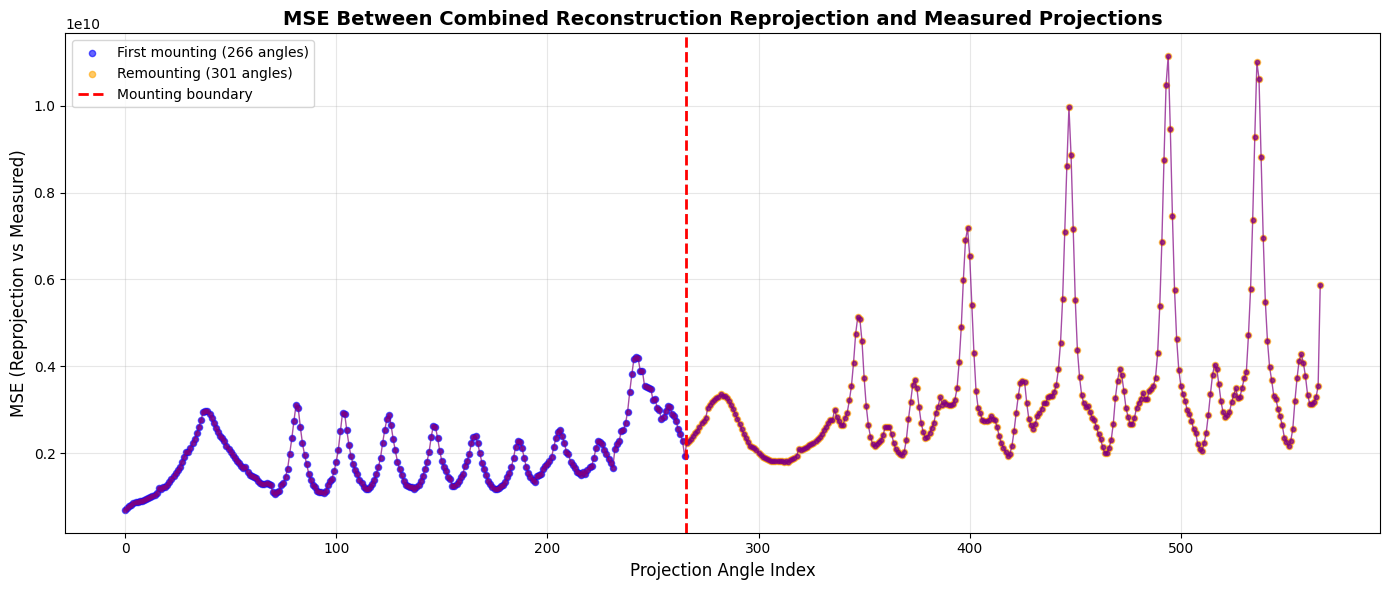


MSE Summary by Mounting:
  First mounting (angles 0-265): mean=1895849472.0000, std=702720896.0000
  Remounting (angles 266-566): mean=3355966720.0000, std=1643420160.0000


In [39]:
# Forward project the combined reconstruction and compute MSE with measured projections
print("Forward projecting combined reconstruction through all angles...")

# Get the reconstruction volume
volume_combined = results_dc1['reconstruction'].to(device).clone()

# Build projector for full geometry
projector_combined = build_mumott_projector(combined_dc.geometry, device=device)

# Get target data from combined_dc
target_data_combined = torch.tensor(
    np.stack([p.data for p in combined_dc.projections]).astype(np.float32),
    device=device, dtype=torch.float32
)
weights_combined = torch.tensor(
    np.stack([p.weights for p in combined_dc.projections]).astype(np.float32),
    device=device, dtype=torch.float32
)

# Forward project
with torch.no_grad():
    spatial_proj = projector_combined(volume_combined)
    predicted = forward_quadrature(
        combined_dc.geometry.probed_coordinates,
        spatial_proj,
        ell_max=ELL_MAX,
    )

print(f"Predicted projections shape: {predicted.shape}")
print(f"Target projections shape: {target_data_combined.shape}")

# Compute MSE per angle (mean over all pixels and detector angles)
mse_per_angle = torch.mean((predicted - target_data_combined)**2, dim=(1, 2, 3)).cpu().numpy()
num_angles = len(mse_per_angle)

print(f"\nMSE per angle shape: {mse_per_angle.shape}")
print(f"MSE statistics:")
print(f"  Mean: {np.mean(mse_per_angle):.6f}")
print(f"  Median: {np.median(mse_per_angle):.6f}")
print(f"  Min: {np.min(mse_per_angle):.6f}")
print(f"  Max: {np.max(mse_per_angle):.6f}")

# Mark which angles belong to first mounting vs remounting
n_first_mounting = len(dc1.projections)
first_mounting_indices = np.arange(n_first_mounting)
remounting_indices = np.arange(n_first_mounting, num_angles)

# Plot MSE as a function of angle index
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(mse_per_angle, 'o-', linewidth=1, markersize=3, alpha=0.7, color='purple')
ax.scatter(first_mounting_indices, mse_per_angle[first_mounting_indices], color='blue', s=20, 
           alpha=0.6, label=f'First mounting ({n_first_mounting} angles)')
ax.scatter(remounting_indices, mse_per_angle[remounting_indices], color='orange', s=20,
           alpha=0.6, label=f'Remounting ({len(remounting_indices)} angles)')

ax.axvline(x=n_first_mounting - 0.5, color='red', linestyle='--', linewidth=2, 
           label='Mounting boundary')

ax.set_xlabel('Projection Angle Index', fontsize=12)
ax.set_ylabel('MSE (Reprojection vs Measured)', fontsize=12)
ax.set_title('MSE Between Combined Reconstruction Reprojection and Measured Projections', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary by mounting
print(f"\nMSE Summary by Mounting:")
print(f"  First mounting (angles 0-{n_first_mounting-1}): mean={np.mean(mse_per_angle[:n_first_mounting]):.4f}, std={np.std(mse_per_angle[:n_first_mounting]):.4f}")
print(f"  Remounting (angles {n_first_mounting}-{num_angles-1}): mean={np.mean(mse_per_angle[n_first_mounting:]):.4f}, std={np.std(mse_per_angle[n_first_mounting:]):.4f}")

# Clean up
del volume_combined, spatial_proj, predicted
torch.cuda.empty_cache()

## 4. Loss Function Comparison

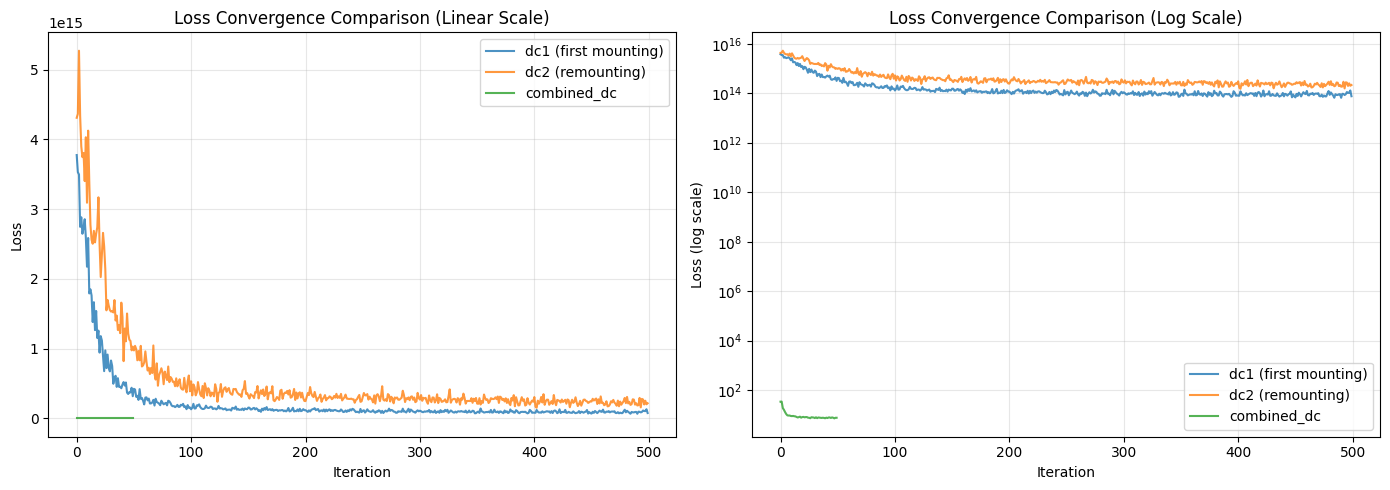


Final Loss Summary:
  dc1 (first mounting): 7.62e+13
  dc2 (remounting):     2.16e+14
  combined_dc:          7.60e+00


In [41]:
# Plot loss curves for all three reconstructions
plt.figure(figsize=(14, 5))

# Linear scale
plt.subplot(1, 2, 1)
try:
    plt.plot(results_dc1['losses'], label='dc1 (first mounting)', alpha=0.8)
except:
    pass
try:
    plt.plot(results_dc2['losses'], label='dc2 (remounting)', alpha=0.8)
except:
    pass
plt.plot(results_combined['losses'], label='combined_dc', alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Convergence Comparison (Linear Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Log scale
plt.subplot(1, 2, 2)
plt.semilogy(results_dc1['losses'], label='dc1 (first mounting)', alpha=0.8)
plt.semilogy(results_dc2['losses'], label='dc2 (remounting)', alpha=0.8)
plt.semilogy(results_combined['losses'], label='combined_dc', alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('Loss Convergence Comparison (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nFinal Loss Summary:")
print(f"  dc1 (first mounting): {results_dc1['final_loss']:.2e}")
print(f"  dc2 (remounting):     {results_dc2['final_loss']:.2e}")
print(f"  combined_dc:          {results_combined['final_loss']:.2e}")

## 5. Interactive Slice and Spherical Harmonics Comparison

In [42]:
# Get number of slices and SH coefficients
num_slices = results_dc1['reconstruction'].shape[0]
num_sh_coeffs = results_dc1['reconstruction'].shape[-1]

print(f"Volume shape: {results_dc1['reconstruction'].shape}")
print(f"Number of slices: {num_slices}")
print(f"Number of SH coefficients: {num_sh_coeffs}")

@interact(slice_idx=(0, num_slices - 1), sh_idx=(0, num_sh_coeffs - 1))
def compare_reconstructions(slice_idx, sh_idx):
    """Interactive comparison of reconstructions across all three DataContainers."""
    
    # Get slices for each reconstruction
    slice_dc1 = results_dc1['reconstruction'][slice_idx, :, :, sh_idx].numpy()
    slice_dc2 = results_dc2['reconstruction'][slice_idx, :, :, sh_idx].numpy()
    slice_combined = results_combined['reconstruction'][slice_idx, :, :, sh_idx].numpy()
    
    # Rotate dc2 image 90 degrees clockwise
    # slice_dc2 = np.rot90(slice_dc2, k=-1)
    
    # Apply mask
    mask_slice = mask[slice_idx]
    slice_dc1_masked = slice_dc1 * mask_slice
    slice_dc2_masked = slice_dc2 * mask_slice
    slice_combined_masked = slice_combined * mask_slice
    
    # Compute common color scale
    all_data = np.concatenate([slice_dc1_masked.flatten(), 
                                slice_dc2_masked.flatten(), 
                                slice_combined_masked.flatten()])
    vmin, vmax = np.percentile(all_data[all_data != 0], [2, 98]) if np.any(all_data != 0) else (0, 1)
    
    # Create figure
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    # Plot dc1
    im0 = axes[0].imshow(slice_dc1_masked, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title(f'dc1 (first mounting)\nSlice {slice_idx}, SH {sh_idx}')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Plot dc2
    im1 = axes[1].imshow(slice_dc2_masked, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title(f'dc2 (remounting)\nSlice {slice_idx}, SH {sh_idx}')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Plot combined
    im2 = axes[2].imshow(slice_combined_masked, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[2].set_title(f'combined_dc\nSlice {slice_idx}, SH {sh_idx}')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Plot difference (combined - mean of dc1 and dc2)
    diff = slice_combined_masked#- 0.5 * (slice_dc1_masked)
    diff_max = np.max(np.abs(diff))
    im3 = axes[3].imshow(diff, cmap='RdBu_r', vmin=-diff_max, vmax=diff_max)
    axes[3].set_title(f'Difference\n(combined - mean(dc1,dc2))')
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046)
    
    plt.tight_layout()
    plt.show()

Volume shape: torch.Size([141, 111, 141, 45])
Number of slices: 141
Number of SH coefficients: 45


interactive(children=(IntSlider(value=70, description='slice_idx', max=140), IntSlider(value=22, description='…

## 6. Principal Direction Analysis (Angle with X-Y Plane)

In [26]:
# Compute principal directions using mumott's SphericalHarmonics
basis_set = SphericalHarmonics(ell_max=ELL_MAX)

# dc1
output_dc1 = basis_set.get_output((results_dc1['reconstruction']).numpy())
directions_dc1 = torch.FloatTensor(output_dc1.eigenvector_1)

# dc2
output_dc2 = basis_set.get_output((results_dc2['reconstruction']).numpy())
directions_dc2 = torch.FloatTensor(output_dc2.eigenvector_1)

# combined
output_combined = basis_set.get_output((results_combined['reconstruction']).numpy())
directions_combined = torch.FloatTensor(output_combined.eigenvector_1)

print(f"Directions shape: {directions_dc1.shape}")

Directions shape: torch.Size([141, 111, 141, 3])


/opt/conda/lib/python3.10/site-packages/mumott/methods/basis_sets/spherical_harmonics.py:404: RuntimeWarning: invalid value encountered in divide
  fractional_anisotropy = fractional_anisotropy / np.sqrt(2*np.sum(eigenvalues**2, axis=-1))


In [27]:
@interact(proj_num=(0, results_dc1['reconstruction'].shape[0] - 1))
def show_angle_with_xy_plane_comparison(proj_num):
    """Interactive visualization of the angle between principal direction and the x-y plane for all three datasets."""
    
    # Get principal directions for each dataset
    dirs_dc1 = directions_dc1[proj_num]
    dirs_dc2 = directions_dc2[proj_num]
    dirs_combined = directions_combined[proj_num]

    slice_mask = torch.tensor(mask[proj_num], dtype=torch.bool)
    # Compute dot product with z-axis (angle with x-y plane)
    z_axis = torch.tensor([0., 0., 1.])
    
    axis = 2
    angle_dc1 = torch.abs(dirs_dc1[..., axis])
    angle_dc2 = torch.abs(dirs_dc2[..., axis])
    angle_combined = torch.abs(dirs_combined[..., axis])

    # angle_dc1 = 90 - torch.rad2deg(torch.arccos(angle_dc1))
    # angle_dc2 = 90 - torch.rad2deg(torch.arccos(angle_dc2))
    # angle_combined = 90 - torch.rad2deg(torch.arccos(angle_combined))

    angle_dc1[~slice_mask] = 0
    angle_dc2[~slice_mask] = 0
    angle_combined[~slice_mask] = 0


    # Rotate dc2 image 90 degrees clockwise
    # angle_dc2 = np.rot90(angle_dc2, k=-1)

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Plot dc1
    im0 = axes[0].imshow(angle_dc1, cmap='viridis', origin='lower')
    axes[0].set_title(f'dc1 (first mounting)\nAngle with X-Y plane (slice {proj_num})')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label='angle (radians)')
    
    # Plot dc2
    im1 = axes[1].imshow(angle_dc2, cmap='viridis', origin='lower')
    axes[1].set_title(f'dc2 (remounting)\nAngle with X-Y plane (slice {proj_num})')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='angle (radians)')
    
    # Plot combined
    im2 = axes[2].imshow(angle_combined, cmap='viridis', origin='lower')
    axes[2].set_title(f'combined_dc\nAngle with X-Y plane (slice {proj_num})')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='z-coordinate of eigenvector')
    
    plt.suptitle('Principal Direction Alignment with Z-axis\n(1 = aligned with z, 0 = in x-y plane)', fontsize=12)
    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=70, description='proj_num', max=140), Output()), _dom_classes=('widget-i…

## 6b. Interactive Spherical Harmonics Exploration

Click on any voxel in the slice visualization to see its spherical harmonic representation:
- **Lobe plot**: 3D surface where radius = |f(θ,φ)|, color indicates sign
- **Surface plot**: Function value as color on unit sphere

In [32]:
# Import the SH visualization module
import sys
sys.path.insert(0, '/myhome/smartt/notebooks')

# Reload modules in case they were updated
import importlib
import mumott_plotting
import mumott_plotting.clickable_explorer
importlib.reload(mumott_plotting.clickable_explorer)
importlib.reload(mumott_plotting)

from mumott_plotting import (
    ClickableSHExplorer,
    plot_sh_lobe,
    plot_sh_surface,
    analyze_sh_coefficients,
)

print("✓ SH visualization loaded!")
print("Note: For click-based interaction, you need to restart the kernel after ipympl installation.")
print("      Alternatively, use the coordinate-based explorer below.")

✓ SH visualization loaded!
Note: For click-based interaction, you need to restart the kernel after ipympl installation.
      Alternatively, use the coordinate-based explorer below.


In [33]:
# Interactive SH Explorer with coordinate sliders
# Use the sliders to select a voxel and see its spherical harmonic representation

import ipywidgets as widgets

# Prepare volumes dict
volumes = {
    'dc1 (first)': results_dc1['reconstruction'].numpy() if hasattr(results_dc1['reconstruction'], 'numpy') else results_dc1['reconstruction'],
    'dc2 (remount)': results_dc2['reconstruction'].numpy() if hasattr(results_dc2['reconstruction'], 'numpy') else results_dc2['reconstruction'],
    'combined': results_combined['reconstruction'].numpy() if hasattr(results_combined['reconstruction'], 'numpy') else results_combined['reconstruction'],
}

# Pre-compute principal directions for all datasets (reuse from above if available)
print("Computing principal directions for all datasets...")
if 'directions_dc1' not in globals():
    basis_set_temp = SphericalHarmonics(ell_max=ELL_MAX)
    output_dc1 = basis_set_temp.get_output(volumes['dc1 (first)'])
    directions_dc1 = torch.FloatTensor(output_dc1.eigenvector_1)
    
    output_dc2 = basis_set_temp.get_output(volumes['dc2 (remount)'])
    directions_dc2 = torch.FloatTensor(output_dc2.eigenvector_1)
    
    output_combined = basis_set_temp.get_output(volumes['combined'])
    directions_combined = torch.FloatTensor(output_combined.eigenvector_1)

directions = {
    'dc1 (first)': directions_dc1,
    'dc2 (remount)': directions_dc2,
    'combined': directions_combined,
}
print("✓ Principal directions computed")

def update_display(slice_idx, y, x, property_type):
    """Update all displays based on selected coordinates."""
    
    n_datasets = len(volumes)
    
    # Create figure with 3 rows per dataset: slice, lobe, surface
    fig = plt.figure(figsize=(6 * n_datasets, 14))
    
    # Compute properties for all datasets for common color scale
    all_props = []
    for name, volume in volumes.items():
        if property_type == 'c0':
            prop = volume[slice_idx, :, :, 0]
        elif property_type == 'norm':
            prop = np.linalg.norm(volume[slice_idx], axis=-1)
        elif property_type == 'anisotropy':
            c0_sq = volume[slice_idx, :, :, 0] ** 2
            total_sq = np.sum(volume[slice_idx] ** 2, axis=-1)
            prop = 1 - c0_sq / (total_sq + 1e-10)
        else:  # principal_angle
            # Compute dot product with z-axis (angle with x-y plane)
            z_axis = torch.tensor([0., 0., 1.])
            dirs = directions[name][slice_idx]
            prop = (dirs @ z_axis).numpy()
        
        prop = prop * mask[slice_idx]
        all_props.append(prop)
    
    # Common color scale
    all_data = np.concatenate([p.flatten() for p in all_props])
    nonzero = all_data[all_data != 0]
    vmin, vmax = np.percentile(nonzero, [2, 98]) if len(nonzero) > 0 else (0, 1)
    
    # Check if in mask
    in_mask = mask[slice_idx, y, x]
    
    # Plot for each dataset
    for i, (name, volume, prop) in enumerate(zip(volumes.keys(), volumes.values(), all_props)):
        # Row 1: Slice image with marker
        ax_slice = fig.add_subplot(3, n_datasets, i + 1)
        ax_slice.imshow(prop, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower')
        ax_slice.plot(x, y, 'r+', markersize=20, markeredgewidth=3)
        ax_slice.set_title(f'{name}\nSlice {slice_idx} @ (y={y}, x={x})', fontsize=10)
        ax_slice.axis('off')
        
        if in_mask:
            coeffs = volume[slice_idx, y, x, :]
            principal_dir = directions[name][slice_idx, y, x].numpy()
            
            # Row 2: Lobe plot with principal direction overlay
            ax_lobe = fig.add_subplot(3, n_datasets, n_datasets + i + 1, projection='3d')
            plot_sh_lobe(coeffs, ELL_MAX, ax=ax_lobe, n_theta=40, n_phi=80,
                        title=f'Lobe (r=|f|)', show_colorbar=False)
            
            # Add principal direction as arrow
            arrow_length = 1.5  # Scale the arrow length
            ax_lobe.quiver(0, 0, 0, 
                          principal_dir[0] * arrow_length, 
                          principal_dir[1] * arrow_length, 
                          principal_dir[2] * arrow_length,
                          color='red', arrow_length_ratio=0.3, linewidth=3, alpha=0.8)
            
            # Row 3: Surface plot with principal direction overlay
            ax_surf = fig.add_subplot(3, n_datasets, 2 * n_datasets + i + 1, projection='3d')
            plot_sh_surface(coeffs, ELL_MAX, ax=ax_surf, n_theta=40, n_phi=80,
                           title=f'Surface (color=f)', show_colorbar=False)
            
            # Add principal direction as arrow
            ax_surf.quiver(0, 0, 0, 
                          principal_dir[0] * arrow_length, 
                          principal_dir[1] * arrow_length, 
                          principal_dir[2] * arrow_length,
                          color='red', arrow_length_ratio=0.3, linewidth=3, alpha=0.8)
        else:
            # Show "outside mask" message
            ax_lobe = fig.add_subplot(3, n_datasets, n_datasets + i + 1)
            ax_lobe.text(0.5, 0.5, '⚠ Outside mask', ha='center', va='center', fontsize=14)
            ax_lobe.axis('off')
            
            ax_surf = fig.add_subplot(3, n_datasets, 2 * n_datasets + i + 1)
            ax_surf.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print coefficient info
    if in_mask:
        print(f"\nCoefficient analysis at slice={slice_idx}, y={y}, x={x}:")
        print("-" * 70)
        for name, volume in volumes.items():
            coeffs = volume[slice_idx, y, x, :]
            principal_dir = directions[name][slice_idx, y, x].numpy()
            analysis = analyze_sh_coefficients(coeffs, ELL_MAX)
            print(f"{name:15s}: power={analysis['total_power']:.3e}, isotropy={analysis['isotropy_ratio']:.1%}, c0={coeffs[0]:.3e}")
            print(f"                 principal_dir=[{principal_dir[0]:6.3f}, {principal_dir[1]:6.3f}, {principal_dir[2]:6.3f}]")

# Create interactive widget
vol_shape = results_dc1['reconstruction'].shape
widgets.interact(
    update_display,
    slice_idx=widgets.IntSlider(min=0, max=vol_shape[0]-1, value=vol_shape[0]//2, description='Slice:', continuous_update=False),
    y=widgets.IntSlider(min=0, max=vol_shape[1]-1, value=vol_shape[1]//2, description='Y coord:', continuous_update=False),
    x=widgets.IntSlider(min=0, max=vol_shape[2]-1, value=vol_shape[2]//2, description='X coord:', continuous_update=False),
    property_type=widgets.Dropdown(
        options=[
            ('Isotropic (c₀)', 'c0'), 
            ('Norm', 'norm'), 
            ('Anisotropy', 'anisotropy'),
            ('Principal Angle (z-axis)', 'principal_angle')
        ], 
        value='c0', 
        description='Property:'
    ),
);

Computing principal directions for all datasets...
✓ Principal directions computed


interactive(children=(IntSlider(value=70, continuous_update=False, description='Slice:', max=140), IntSlider(v…

## 7. Summary Statistics

In [34]:
# Print reconstruction summary
print("=" * 60)
print("RECONSTRUCTION SUMMARY")
print("=" * 60)
print(f"\nParameters:")
print(f"  ell_max: {ELL_MAX}")
print(f"  iterations: {MAXITER_ADAMW}")
print(f"  learning rate: {LR}")
print(f"  regularization weight: {REG_WEIGHT}")
print(f"  batch size: {BATCH_SIZE}")

print(f"\nResults:")
print(f"  {'Dataset':<20} {'Projections':<15} {'Final Loss':<15} {'Time (s)':<10}")
print(f"  {'-'*60}")
print(f"  {'dc1 (first mount)':<20} {len(dc1.projections):<15} {results_dc1['final_loss']:<15.2e} {results_dc1['time']:<10.1f}")
print(f"  {'dc2 (remounting)':<20} {len(dc2.projections):<15} {results_dc2['final_loss']:<15.2e} {results_dc2['time']:<10.1f}")
print(f"  {'combined_dc':<20} {len(combined_dc.projections):<15} {results_combined['final_loss']:<15.2e} {results_combined['time']:<10.1f}")

RECONSTRUCTION SUMMARY

Parameters:
  ell_max: 8
  iterations: 200
  learning rate: 10
  regularization weight: 10.0
  batch size: (30, 30)

Results:
  Dataset              Projections     Final Loss      Time (s)  
  ------------------------------------------------------------
  dc1 (first mount)    266             7.62e+13        335.0     
  dc2 (remounting)     301             2.16e+14        343.8     
  combined_dc          567             1.28e+15        449.4     


In [35]:
# Save all reconstruction results
SAVE_RESULTS = True  # Set to False to skip saving

if SAVE_RESULTS:
    import pickle
    
    save_data = {
        'results_dc1': results_dc1,
        'results_dc2': results_dc2,
        'results_combined': results_combined,
        'parameters': {
            'ELL_MAX': ELL_MAX,
            'MAXITER_ADAMW': MAXITER_ADAMW,
            'LR': LR,
            'REG_WEIGHT': REG_WEIGHT,
            'BATCH_SIZE': BATCH_SIZE
        }
    }
    
    with open(RESULTS_PATH, 'wb') as f:
        pickle.dump(save_data, f)
    
    print(f"✓ Results saved to {RESULTS_PATH}")
    print(f"  File size: {os.path.getsize(RESULTS_PATH) / 1024 / 1024:.1f} MB")
    print(f"\nTo load these results later, set LOAD_SAVED_RESULTS = True in the earlier cell.")
else:
    print("Saving disabled. Set SAVE_RESULTS = True to save results.")

✓ Results saved to /myhome/smartt/notebooks/remounting_results.pkl
  File size: 1136.5 MB

To load these results later, set LOAD_SAVED_RESULTS = True in the earlier cell.


## 8. Save Results

## 9. Uncertainty Estimation via Multiple Reconstructions

Run the reconstruction multiple times with different random initializations/batches to estimate uncertainty in both the spherical harmonic coefficients and principal directions.

In [49]:
# Uncertainty estimation parameters
N_RUNS = 5  # Number of reconstruction runs for uncertainty estimation
UNCERTAINTY_DC = dc2  # DataContainer to use for uncertainty estimation
UNCERTAINTY_DC_NAME = "dc2"

print(f"Uncertainty Estimation Configuration:")
print(f"  DataContainer: {UNCERTAINTY_DC_NAME} ({len(UNCERTAINTY_DC.projections)} projections)")
print(f"  Number of runs: {N_RUNS}")
print(f"  ell_max: {ELL_MAX}")
print(f"  iterations: {MAXITER_ADAMW}")
print(f"  batch_size: {BATCH_SIZE}")

Uncertainty Estimation Configuration:
  DataContainer: dc2 (301 projections)
  Number of runs: 5
  ell_max: 8
  iterations: 200
  batch_size: (30, 30)


In [50]:
# Run multiple reconstructions
print(f"Running {N_RUNS} reconstructions for uncertainty estimation...")
print("=" * 60)

all_reconstructions = []
all_results = []

for run_idx in range(N_RUNS):
    print(f"\n--- Run {run_idx + 1}/{N_RUNS} ---")
    
    result = run_pytorch_reconstruction(
        UNCERTAINTY_DC, ELL_MAX, MAXITER_ADAMW, LR, REG_WEIGHT, 
        reg_type='laplacian', verbose=True, batch_size=BATCH_SIZE
    )
    
    all_reconstructions.append(result['reconstruction'].numpy())
    all_results.append(result)
    
    print(f"  Final loss: {result['final_loss']:.2e}, Time: {result['time']:.1f}s")
    torch.cuda.empty_cache()

# Stack all reconstructions into a single array
all_reconstructions = np.stack(all_reconstructions, axis=0)  # Shape: (N_RUNS, Z, Y, X, n_coeffs)
print(f"\nAll reconstructions shape: {all_reconstructions.shape}")
print("✓ All reconstructions completed!")

Running 5 reconstructions for uncertainty estimation...

--- Run 1/5 ---
Running PyTorch AdamW (200 iterations, batch_size: 30 → 30 (linear schedule))...
  Total projections: 301


  0%|          | 0/200 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
100%|██████████| 200/200 [02:32<00:00,  1.31it/s, status=Iter 200: loss=4.609e+14, bs=30]


  Final loss: 4.61e+14, Time: 152.5s

--- Run 2/5 ---
Running PyTorch AdamW (200 iterations, batch_size: 30 → 30 (linear schedule))...
  Total projections: 301


100%|██████████| 200/200 [02:30<00:00,  1.33it/s, status=Iter 200: loss=5.079e+14, bs=30]


  Final loss: 5.08e+14, Time: 150.9s

--- Run 3/5 ---
Running PyTorch AdamW (200 iterations, batch_size: 30 → 30 (linear schedule))...
  Total projections: 301


...

  Final loss: 3.98e+14, Time: 151.5s

--- Run 4/5 ---
Running PyTorch AdamW (200 iterations, batch_size: 30 → 30 (linear schedule))...
  Total projections: 301


100%|██████████| 200/200 [02:28<00:00,  1.34it/s, status=Iter 200: loss=4.469e+14, bs=30]


  Final loss: 4.47e+14, Time: 148.7s

--- Run 5/5 ---
Running PyTorch AdamW (200 iterations, batch_size: 30 → 30 (linear schedule))...
  Total projections: 301


100%|██████████| 200/200 [02:28<00:00,  1.35it/s, status=Iter 200: loss=7.054e+14, bs=30]


  Final loss: 7.05e+14, Time: 148.5s

All reconstructions shape: (5, 141, 111, 141, 45)
✓ All reconstructions completed!


In [51]:
# Compute mean and variance of reconstructions
mean_reconstruction = np.mean(all_reconstructions, axis=0)
var_reconstruction = np.var(all_reconstructions, axis=0)

print(f"Mean reconstruction shape: {mean_reconstruction.shape}")
print(f"Variance reconstruction shape: {var_reconstruction.shape}")

# Compute principal directions for mean reconstruction
basis_set_unc = SphericalHarmonics(ell_max=ELL_MAX)
output_mean = basis_set_unc.get_output(mean_reconstruction)
directions_mean = torch.FloatTensor(output_mean.eigenvector_1)
print(f"Mean principal directions shape: {directions_mean.shape}")

# Compute principal directions for each individual reconstruction
all_directions = []
for i, recon in enumerate(all_reconstructions):
    output_i = basis_set_unc.get_output(recon)
    directions_i = torch.FloatTensor(output_i.eigenvector_1)
    all_directions.append(directions_i)
    print(f"  Computed directions for run {i+1}/{N_RUNS}")

all_directions = torch.stack(all_directions, dim=0)  # Shape: (N_RUNS, Z, Y, X, 3)
print(f"\nAll directions shape: {all_directions.shape}")

# Compute variance of principal directions
# Note: Principal directions can point in opposite directions (v and -v are equivalent)
# We align them to the mean direction before computing variance
mean_directions = torch.mean(all_directions, dim=0)
mean_directions_norm = mean_directions / (torch.norm(mean_directions, dim=-1, keepdim=True) + 1e-10)

# Align all directions to mean (flip if pointing opposite)
aligned_directions = []
for i in range(N_RUNS):
    dirs_i = all_directions[i]
    # Compute dot product with mean
    dot_product = torch.sum(dirs_i * mean_directions_norm, dim=-1, keepdim=True)
    # Flip if negative dot product
    aligned_i = torch.where(dot_product < 0, -dirs_i, dirs_i)
    aligned_directions.append(aligned_i)

aligned_directions = torch.stack(aligned_directions, dim=0)
var_directions = torch.var(aligned_directions, dim=0)  # Shape: (Z, Y, X, 3)

# Compute total directional variance (sum of variances in x, y, z)
total_var_directions = torch.sum(var_directions, dim=-1)  # Shape: (Z, Y, X)

print(f"Variance of aligned directions shape: {var_directions.shape}")
print(f"Total directional variance shape: {total_var_directions.shape}")

Mean reconstruction shape: (141, 111, 141, 45)
Variance reconstruction shape: (141, 111, 141, 45)
Mean principal directions shape: torch.Size([141, 111, 141, 3])
  Computed directions for run 1/5
  Computed directions for run 2/5
  Computed directions for run 3/5
  Computed directions for run 4/5
  Computed directions for run 5/5

All directions shape: torch.Size([5, 141, 111, 141, 3])
Variance of aligned directions shape: torch.Size([141, 111, 141, 3])
Total directional variance shape: torch.Size([141, 111, 141])


### 9.1 Visualize Mean Reconstruction and Principal Directions

**Key concepts:**

- **Reconstruction uncertainty**: Standard deviation of SH coefficients across multiple reconstruction runs with different random batch selections
- **Principal direction**: First eigenvector of the diffusion tensor (shows main orientation)  
- **Direction uncertainty**: Measures how much the principal direction varies across runs
  - Computed as: `sqrt(var_x + var_y + var_z)` where variances are across N runs
  - Directions are aligned before computing variance (v and -v represent the same direction)

In [52]:
# Interactive visualization of mean reconstruction
@interact(slice_idx=(0, mean_reconstruction.shape[0] - 1), sh_idx=(0, mean_reconstruction.shape[-1] - 1))
def visualize_mean_reconstruction(slice_idx, sh_idx):
    """Visualize mean reconstruction with SH coefficients and principal direction."""
    
    # Get mean slice
    mean_slice = mean_reconstruction[slice_idx, :, :, sh_idx]
    std_slice = np.sqrt(var_reconstruction[slice_idx, :, :, sh_idx])
    
    # Apply mask
    mask_slice = mask[slice_idx]
    mean_slice_masked = mean_slice * mask_slice
    std_slice_masked = std_slice * mask_slice
    
    # Principal direction angle with z-axis
    dirs_mean = directions_mean[slice_idx]
    angle_mean = torch.abs(dirs_mean[..., 2]).numpy()  # z-component
    angle_mean_masked = angle_mean * mask_slice
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Mean reconstruction
    vmin_mean, vmax_mean = np.percentile(mean_slice_masked[mean_slice_masked != 0], [2, 98]) if np.any(mean_slice_masked != 0) else (0, 1)
    im0 = axes[0].imshow(mean_slice_masked, cmap='viridis', vmin=vmin_mean, vmax=vmax_mean, origin='lower')
    axes[0].set_title(f'Mean Reconstruction\nSlice {slice_idx}, SH {sh_idx}')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Standard deviation of reconstruction
    vmin_std, vmax_std = np.percentile(std_slice_masked[std_slice_masked != 0], [2, 98]) if np.any(std_slice_masked != 0) else (0, 1)
    im1 = axes[1].imshow(std_slice_masked, cmap='hot', vmin=0, vmax=vmax_std, origin='lower')
    axes[1].set_title(f'Std Dev of Reconstruction\nSlice {slice_idx}, SH {sh_idx}')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Principal direction (z-component)
    im2 = axes[2].imshow(angle_mean_masked, cmap='viridis', vmin=0, vmax=1, origin='lower')
    axes[2].set_title(f'Principal Direction (|z-component|)\nSlice {slice_idx}')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='|z|')
    
    plt.suptitle(f'Mean Reconstruction from {N_RUNS} runs', fontsize=12)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=70, description='slice_idx', max=140), IntSlider(value=22, description='…

### 9.2 Visualize Principal Direction Uncertainty

How direction uncertainty is calculated:
1. For each of the N reconstruction runs, compute principal directions (first eigenvector)
2. Align all directions to mean direction (flip if dot product < 0)
3. Compute variance of aligned directions across runs: `var_x, var_y, var_z`
4. Total uncertainty = `sqrt(var_x + var_y + var_z)`

In [53]:
# Interactive visualization of principal direction uncertainty
@interact(slice_idx=(0, mean_reconstruction.shape[0] - 1))
def visualize_direction_variance(slice_idx):
    """Visualize uncertainty (std dev) of principal directions across all runs."""
    
    mask_slice = mask[slice_idx]
    
    # Get std dev components (sqrt of variance)
    std_x = np.sqrt(var_directions[slice_idx, :, :, 0].numpy()) * mask_slice
    std_y = np.sqrt(var_directions[slice_idx, :, :, 1].numpy()) * mask_slice
    std_z = np.sqrt(var_directions[slice_idx, :, :, 2].numpy()) * mask_slice
    total_std = np.sqrt(total_var_directions[slice_idx].numpy()) * mask_slice
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Common color scale for components
    std_max = max(np.max(std_x), np.max(std_y), np.max(std_z))
    
    # Std dev in x
    im0 = axes[0, 0].imshow(std_x, cmap='hot', vmin=0, vmax=std_max, origin='lower')
    axes[0, 0].set_title(f'Std Dev (x-component)\nSlice {slice_idx}')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)
    
    # Std dev in y
    im1 = axes[0, 1].imshow(std_y, cmap='hot', vmin=0, vmax=std_max, origin='lower')
    axes[0, 1].set_title(f'Std Dev (y-component)\nSlice {slice_idx}')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)
    
    # Std dev in z
    im2 = axes[1, 0].imshow(std_z, cmap='hot', vmin=0, vmax=std_max, origin='lower')
    axes[1, 0].set_title(f'Std Dev (z-component)\nSlice {slice_idx}')
    axes[1, 0].axis('off')
    plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)
    
    # Total std dev (sqrt of sum of variances)
    vmax_total = np.percentile(total_std[total_std > 0], 98) if np.any(total_std > 0) else 1
    im3 = axes[1, 1].imshow(total_std, cmap='hot', vmin=0, vmax=vmax_total, origin='lower')
    axes[1, 1].set_title(f'Total Direction Std Dev\nSlice {slice_idx}')
    axes[1, 1].axis('off')
    plt.colorbar(im3, ax=axes[1, 1], fraction=0.046)
    
    plt.suptitle(f'Principal Direction Uncertainty from {N_RUNS} runs\n(Std Dev = sqrt(variance across runs); Higher values = more uncertainty)', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Statistics
    masked_total_std = total_std[mask_slice > 0]
    print(f"\nDirection Uncertainty Statistics (slice {slice_idx}):")
    print(f"  Mean total std dev: {np.mean(masked_total_std):.4e}")
    print(f"  Max total std dev:  {np.max(masked_total_std):.4e}")
    print(f"  Std of total std dev: {np.std(masked_total_std):.4e}")

interactive(children=(IntSlider(value=70, description='slice_idx', max=140), Output()), _dom_classes=('widget-…

### 9.3 Interactive SH Exploration with Uncertainty

In [54]:
# Interactive SH exploration showing mean and variance at selected voxel
def update_uncertainty_display(slice_idx, y, x, property_type):
    """Update display showing mean reconstruction and uncertainty at selected voxel."""
    
    # Check if in mask
    in_mask = mask[slice_idx, y, x]
    
    # Compute property for slice visualization
    if property_type == 'c0':
        prop = mean_reconstruction[slice_idx, :, :, 0]
        var_prop = var_reconstruction[slice_idx, :, :, 0]
    elif property_type == 'norm':
        prop = np.linalg.norm(mean_reconstruction[slice_idx], axis=-1)
        var_prop = np.sum(var_reconstruction[slice_idx], axis=-1)
    elif property_type == 'direction_var':
        prop = total_var_directions[slice_idx].numpy()
        var_prop = prop  # Same for visualization
    else:  # principal_angle
        dirs = directions_mean[slice_idx]
        prop = torch.abs(dirs[..., 2]).numpy()
        var_prop = var_directions[slice_idx, :, :, 2].numpy()
    
    prop = prop * mask[slice_idx]
    var_prop = var_prop * mask[slice_idx]
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    
    # Row 1: Slice views (mean and variance)
    ax_mean = fig.add_subplot(2, 3, 1)
    vmin, vmax = np.percentile(prop[prop != 0], [2, 98]) if np.any(prop != 0) else (0, 1)
    im_mean = ax_mean.imshow(prop, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower')
    ax_mean.plot(x, y, 'r+', markersize=20, markeredgewidth=3)
    ax_mean.set_title(f'Mean Reconstruction\n{property_type}, Slice {slice_idx}')
    ax_mean.axis('off')
    plt.colorbar(im_mean, ax=ax_mean, fraction=0.046)
    
    ax_var = fig.add_subplot(2, 3, 2)
    vmax_var = np.percentile(var_prop[var_prop != 0], 98) if np.any(var_prop != 0) else 1
    im_var = ax_var.imshow(var_prop, cmap='hot', vmin=0, vmax=vmax_var, origin='lower')
    ax_var.plot(x, y, 'r+', markersize=20, markeredgewidth=3)
    ax_var.set_title(f'Variance\nSlice {slice_idx}')
    ax_var.axis('off')
    plt.colorbar(im_var, ax=ax_var, fraction=0.046)
    
    # Direction variance
    ax_dir_var = fig.add_subplot(2, 3, 3)
    dir_var_slice = total_var_directions[slice_idx].numpy() * mask[slice_idx]
    vmax_dir = np.percentile(dir_var_slice[dir_var_slice > 0], 98) if np.any(dir_var_slice > 0) else 1
    im_dir = ax_dir_var.imshow(dir_var_slice, cmap='hot', vmin=0, vmax=vmax_dir, origin='lower')
    ax_dir_var.plot(x, y, 'r+', markersize=20, markeredgewidth=3)
    ax_dir_var.set_title(f'Direction Variance\nSlice {slice_idx}')
    ax_dir_var.axis('off')
    plt.colorbar(im_dir, ax=ax_dir_var, fraction=0.046)
    
    if in_mask:
        # Row 2: SH lobe plots for mean and individual runs
        mean_coeffs = mean_reconstruction[slice_idx, y, x, :]
        mean_principal_dir = directions_mean[slice_idx, y, x].numpy()
        
        # Mean SH lobe
        ax_mean_lobe = fig.add_subplot(2, 3, 4, projection='3d')
        plot_sh_lobe(mean_coeffs, ELL_MAX, ax=ax_mean_lobe, n_theta=40, n_phi=80,
                    title='Mean SH Lobe', show_colorbar=False)
        # Add mean principal direction
        arrow_length = 1.5
        ax_mean_lobe.quiver(0, 0, 0, 
                          mean_principal_dir[0] * arrow_length, 
                          mean_principal_dir[1] * arrow_length, 
                          mean_principal_dir[2] * arrow_length,
                          color='red', arrow_length_ratio=0.3, linewidth=3, alpha=0.8)
        
        # Show all principal directions from different runs
        ax_dirs = fig.add_subplot(2, 3, 5, projection='3d')
        ax_dirs.set_title(f'Principal Directions\n({N_RUNS} runs)')
        
        # Plot unit sphere for reference
        u = np.linspace(0, 2 * np.pi, 30)
        v = np.linspace(0, np.pi, 20)
        xs = 0.3 * np.outer(np.cos(u), np.sin(v))
        ys = 0.3 * np.outer(np.sin(u), np.sin(v))
        zs = 0.3 * np.outer(np.ones(np.size(u)), np.cos(v))
        ax_dirs.plot_surface(xs, ys, zs, alpha=0.1, color='gray')
        
        # Plot individual directions from each run
        colors = plt.cm.viridis(np.linspace(0, 1, N_RUNS))
        for i in range(N_RUNS):
            dir_i = aligned_directions[i, slice_idx, y, x].numpy()
            ax_dirs.quiver(0, 0, 0, dir_i[0], dir_i[1], dir_i[2],
                          color=colors[i], arrow_length_ratio=0.2, linewidth=2, alpha=0.7,
                          label=f'Run {i+1}')
        
        # Plot mean direction
        ax_dirs.quiver(0, 0, 0, mean_principal_dir[0], mean_principal_dir[1], mean_principal_dir[2],
                      color='red', arrow_length_ratio=0.3, linewidth=4, alpha=1.0, label='Mean')
        
        ax_dirs.set_xlim([-1.2, 1.2])
        ax_dirs.set_ylim([-1.2, 1.2])
        ax_dirs.set_zlim([-1.2, 1.2])
        ax_dirs.set_xlabel('X')
        ax_dirs.set_ylabel('Y')
        ax_dirs.set_zlabel('Z')
        
        # Summary statistics
        ax_stats = fig.add_subplot(2, 3, 6)
        ax_stats.axis('off')
        
        # Compute statistics
        coeffs_at_voxel = all_reconstructions[:, slice_idx, y, x, :]
        mean_c0 = np.mean(coeffs_at_voxel[:, 0])
        std_c0 = np.std(coeffs_at_voxel[:, 0])
        
        dir_var_at_voxel = total_var_directions[slice_idx, y, x].item()
        
        stats_text = f"""Voxel Statistics at (slice={slice_idx}, y={y}, x={x})
        
Mean c₀: {mean_c0:.4e} ± {std_c0:.4e}
Direction variance: {dir_var_at_voxel:.4e}

Mean principal direction:
  [{mean_principal_dir[0]:6.3f}, {mean_principal_dir[1]:6.3f}, {mean_principal_dir[2]:6.3f}]

Individual run directions:"""
        
        for i in range(N_RUNS):
            dir_i = aligned_directions[i, slice_idx, y, x].numpy()
            stats_text += f"\n  Run {i+1}: [{dir_i[0]:6.3f}, {dir_i[1]:6.3f}, {dir_i[2]:6.3f}]"
        
        ax_stats.text(0.1, 0.9, stats_text, transform=ax_stats.transAxes, 
                     fontsize=10, verticalalignment='top', fontfamily='monospace')
    else:
        # Outside mask
        for i in range(4, 7):
            ax = fig.add_subplot(2, 3, i)
            ax.text(0.5, 0.5, '⚠ Outside mask', ha='center', va='center', fontsize=14)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
vol_shape = mean_reconstruction.shape
widgets.interact(
    update_uncertainty_display,
    slice_idx=widgets.IntSlider(min=0, max=vol_shape[0]-1, value=vol_shape[0]//2, description='Slice:', continuous_update=False),
    y=widgets.IntSlider(min=0, max=vol_shape[1]-1, value=vol_shape[1]//2, description='Y coord:', continuous_update=False),
    x=widgets.IntSlider(min=0, max=vol_shape[2]-1, value=vol_shape[2]//2, description='X coord:', continuous_update=False),
    property_type=widgets.Dropdown(
        options=[
            ('Isotropic (c₀)', 'c0'), 
            ('Norm', 'norm'), 
            ('Principal Angle', 'principal_angle'),
            ('Direction Variance', 'direction_var')
        ], 
        value='c0', 
        description='Property:'
    ),
);

interactive(children=(IntSlider(value=70, continuous_update=False, description='Slice:', max=140), IntSlider(v…

### 9.4 Uncertainty Summary Statistics

In [55]:
# Summary statistics for uncertainty estimation
print("=" * 70)
print("UNCERTAINTY ESTIMATION SUMMARY")
print("=" * 70)

# Flatten mask for indexing
mask_flat = mask.flatten().astype(bool)

# Reconstruction statistics
mean_flat = mean_reconstruction.reshape(-1, mean_reconstruction.shape[-1])
var_flat = var_reconstruction.reshape(-1, var_reconstruction.shape[-1])
std_flat = np.sqrt(var_flat)

print(f"\n1. Reconstruction Statistics ({N_RUNS} runs):")
print(f"   {'Coefficient':<12} {'Mean':<15} {'Std Dev (avg)':<15} {'Std Dev (max)':<15}")
print(f"   {'-'*55}")
for i in range(min(5, mean_reconstruction.shape[-1])):  # Show first 5 coefficients
    mean_val = np.mean(mean_flat[mask_flat, i])
    std_val = np.mean(std_flat[mask_flat, i])
    max_std = np.max(std_flat[mask_flat, i])
    print(f"   c_{i:<10} {mean_val:<15.3e} {std_val:<15.3e} {max_std:<15.3e}")

# Direction variance statistics
dir_var_flat = total_var_directions.numpy().flatten()
dir_std_flat = np.sqrt(dir_var_flat)
print(f"\n2. Principal Direction Uncertainty Statistics:")
print(f"   Mean std dev:     {np.mean(dir_std_flat[mask_flat]):.4e}")
print(f"   Median std dev:   {np.median(dir_std_flat[mask_flat]):.4e}")
print(f"   Max std dev:      {np.max(dir_std_flat[mask_flat]):.4e}")
print(f"   Std of std dev:   {np.std(dir_std_flat[mask_flat]):.4e}")
print(f"   ---")
print(f"   (Direction std dev = sqrt(var_x + var_y + var_z))")
print(f"   (where var_x, var_y, var_z are variances across {N_RUNS} runs)")

# Loss statistics across runs
print(f"\n3. Final Loss Statistics:")
all_losses = [r['final_loss'] for r in all_results]
print(f"   Mean final loss: {np.mean(all_losses):.2e}")
print(f"   Std final loss:  {np.std(all_losses):.2e}")
print(f"   Min final loss:  {np.min(all_losses):.2e}")
print(f"   Max final loss:  {np.max(all_losses):.2e}")

# Time statistics
print(f"\n4. Timing Statistics:")
all_times = [r['time'] for r in all_results]
print(f"   Mean time per run: {np.mean(all_times):.1f}s")
print(f"   Total time:        {np.sum(all_times):.1f}s")

UNCERTAINTY ESTIMATION SUMMARY

1. Reconstruction Statistics (5 runs):
   Coefficient  Mean            Std Dev (avg)   Std Dev (max)  
   -------------------------------------------------------
   c_0          2.900e+02       9.096e+00       2.841e+01      
   c_1          1.136e+02       7.976e+00       3.032e+01      
   c_2          1.261e+01       7.775e+00       2.767e+01      
   c_3          4.081e+01       1.682e+01       5.851e+01      
   c_4          9.730e+00       9.853e+00       3.020e+01      

2. Principal Direction Uncertainty Statistics:
   Mean std dev:     8.0370e-02
   Median std dev:   4.9251e-02
   Max std dev:      1.0846e+00
   Std of std dev:   1.0126e-01
   ---
   (Direction std dev = sqrt(var_x + var_y + var_z))
   (where var_x, var_y, var_z are variances across 5 runs)

3. Final Loss Statistics:
   Mean final loss: 5.04e+14
   Std final loss:  1.07e+14
   Min final loss:  3.98e+14
   Max final loss:  7.05e+14

4. Timing Statistics:
   Mean time per run: 150

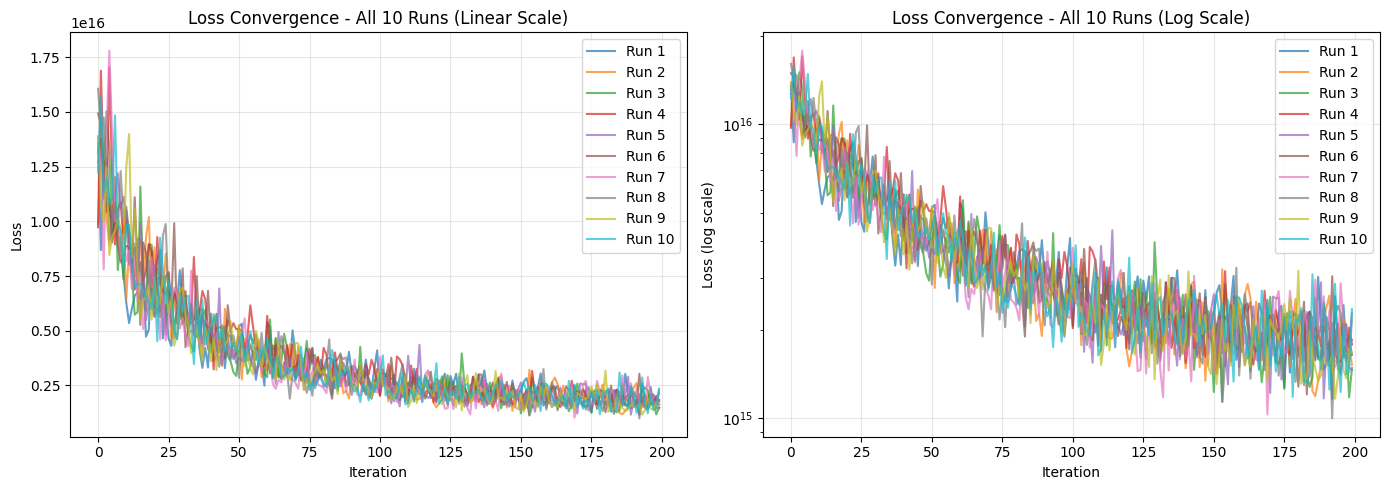

In [43]:
# Plot loss curves for all uncertainty runs
plt.figure(figsize=(14, 5))

# Linear scale
plt.subplot(1, 2, 1)
for i, result in enumerate(all_results):
    plt.plot(result['losses'], alpha=0.7, label=f'Run {i+1}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Loss Convergence - All {N_RUNS} Runs (Linear Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Log scale
plt.subplot(1, 2, 2)
for i, result in enumerate(all_results):
    plt.semilogy(result['losses'], alpha=0.7, label=f'Run {i+1}')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title(f'Loss Convergence - All {N_RUNS} Runs (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()